In [163]:
import pandas as pd
import numpy as np

In [171]:
# Define paths

META_PATH = "../the-building-data-genome-project/data/raw/meta_open.csv"
INTERIM_PATH = "../data/interim/"
PROCESSED_PATH = "../data/processed/"

meta = pd.read_csv(META_PATH)
meta.head()

,uid,dataend,datastart,energystarscore,heatingtype,industry,mainheatingtype,numberoffloors,occupants,primaryspaceusage,rating,sqft,sqm,subindustry,timezone,yearbuilt,nickname,primaryspaceuse_abbrev,newweatherfilename
0,PrimClass_Everett,31-12-2012 23:00,01-01-2012 00:00,NaN,NaN,Education,NaN,NaN,NaN,Primary/Secondary Classroom,NaN,105530.0,9804.053590,Primary/Secondary School,America/New_York,NaN,Everett,PrimClass,weather12.csv
1,UnivClass_Clifford,31-12-2015 23:00,01-01-2015 00:00,NaN,NaN,Education,NaN,NaN,NaN,College Classroom,NaN,56969.0,5292.591007,College/University,America/New_York,1967,Clifford,UnivClass,weather2.csv
2,Office_Elizabeth,31-12-2012 23:00,01-01-2012 00:00,NaN,NaN,Commercial Property,NaN,NaN,NaN,Office,NaN,294651.0,27373.961850,Commercial Real Estate,America/Los_Angeles,NaN,Elizabeth,Office,weather22.csv
3,Office_Ellie,31-12-2012 23:00,01-01-2012 00:00,NaN,NaN,Commercial Property,NaN,NaN,NaN,Office,NaN,496517.0,46127.918850,Bank/Financial Services,America/Los_Angeles,NaN,Ellie,Office,weather28.csv
4,PrimClass_Elisabeth,31-12-2012 23:00,01-01-2012 00:00,NaN,NaN,Education,NaN,NaN,NaN,Primary/Secondary Classroom,NaN,233062.0,21652.158990,Primary/Secondary School,America/New_York,NaN,Elisabeth,PrimClass,weather23.csv


In [173]:
buildings = [
    "PrimClass_Uma",
    "Office_Maryann",
    "Office_Mick"
]

for building in buildings:

    print("Processing:", building)

    df = pd.read_csv(INTERIM_PATH + f"{building}_interim.csv")

    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

    df = df.set_index("timestamp")
    df = df.sort_index()

    # find timezone
    tz = meta.loc[meta["uid"] == building, "timezone"].values[0]

    print("Timezone:", tz)

    # convert timezone
    df.index = df.index.tz_convert(tz)

    # remove timezone for ML compatibility
    df.index = df.index.tz_localize(None)

    # ===== FEATURE ENGINEERING =====

    df["hour"] = df.index.hour
    df["day_of_week"] = df.index.dayofweek
    df["month"] = df.index.month

    df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
    df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)

    df["dow_sin"] = np.sin(2*np.pi*df["day_of_week"]/7)
    df["dow_cos"] = np.cos(2*np.pi*df["day_of_week"]/7)

    df["is_weekend"] = df["day_of_week"].isin([5,6]).astype(int)

    # lag features
    df["lag_1"] = df["energy"].shift(1)
    df["lag_24"] = df["energy"].shift(24)
    df["lag_168"] = df["energy"].shift(168)

    # rolling stats
    df["rolling_mean_24"] = df["energy"].rolling(24).mean()
    df["rolling_std_24"] = df["energy"].rolling(24).std()

    df["rolling_mean_168"] = df["energy"].rolling(168).mean()

    # change features
    df["diff_1"] = df["energy"].diff()
    df["pct_change"] = df["energy"].pct_change()

    df = df.dropna()

    print("Final shape:", df.shape)

    # save
    df.to_csv(PROCESSED_PATH + f"{building}_features.csv")

    print("Saved:", building)

Processing: PrimClass_Uma
Timezone: Asia/Singapore
Final shape: (8592, 17)
Saved: PrimClass_Uma
Processing: Office_Maryann
Timezone: America/Chicago
Final shape: (8592, 17)
Saved: Office_Maryann
Processing: Office_Mick
Timezone: America/Chicago
Final shape: (8592, 17)
Saved: Office_Mick


### Validating Feature Behaviour 

#### PrimClass_Uma

In [193]:
df = pd.read_csv(PROCESSED_PATH + "PrimClass_Uma_features.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.set_index("timestamp")

df.head()

,energy,hour,day_of_week,month,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend,lag_1,lag_24,lag_168,rolling_mean_24,rolling_std_24,rolling_mean_168,diff_1,pct_change
timestamp,,,,,,,,,,,,,,,,,
2012-02-09 00:00:00,7.0,0,3,2,0.000000,1.000000,0.433884,-0.900969,0,7.0,11.0,6.0,16.708333,10.402672,13.471265,0.0,0.000000
2012-02-09 01:00:00,8.0,1,3,2,0.258819,0.965926,0.433884,-0.900969,0,7.0,11.0,8.0,16.583333,10.491888,13.471265,1.0,0.142857
2012-02-09 02:00:00,4.0,2,3,2,0.500000,0.866025,0.433884,-0.900969,0,8.0,6.0,4.0,16.500000,10.587113,13.471265,-4.0,-0.500000
2012-02-09 03:00:00,6.0,3,3,2,0.707107,0.707107,0.433884,-0.900969,0,4.0,9.0,7.0,16.375000,10.696657,13.465312,2.0,0.500000
2012-02-09 04:00:00,7.0,4,3,2,0.866025,0.500000,0.433884,-0.900969,0,6.0,9.0,6.0,16.291667,10.764188,13.471265,1.0,0.166667


In [195]:
# Find unique timezones

meta["timezone"].unique()

array(['America/New_York', 'America/Los_Angeles', 'Europe/London',
       'America/Denver', 'America/Chicago', 'Asia/Singapore',
       'Europe/Zurich', 'America/Phoenix'], dtype=object)

<Axes: title={'center': 'Energy Consumption Over Time'}, xlabel='timestamp'>

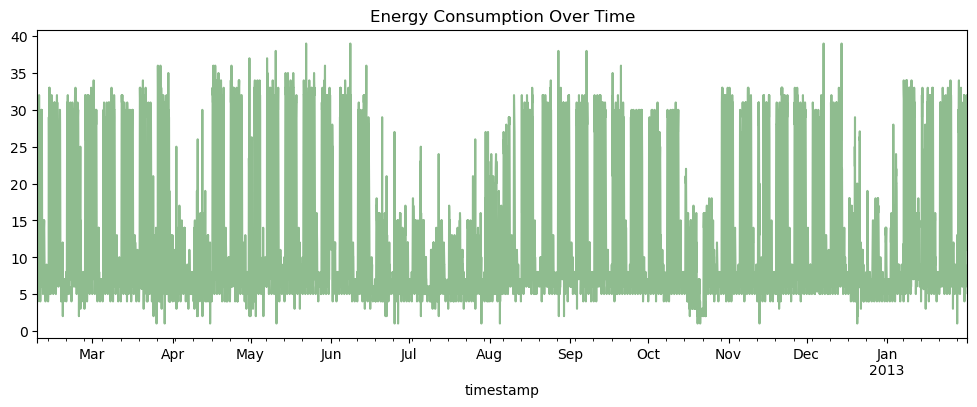

In [221]:
df["energy"].plot(figsize=(12,4), title = 'Energy Consumption Over Time', color = 'darkseagreen')

<Axes: xlabel='timestamp'>

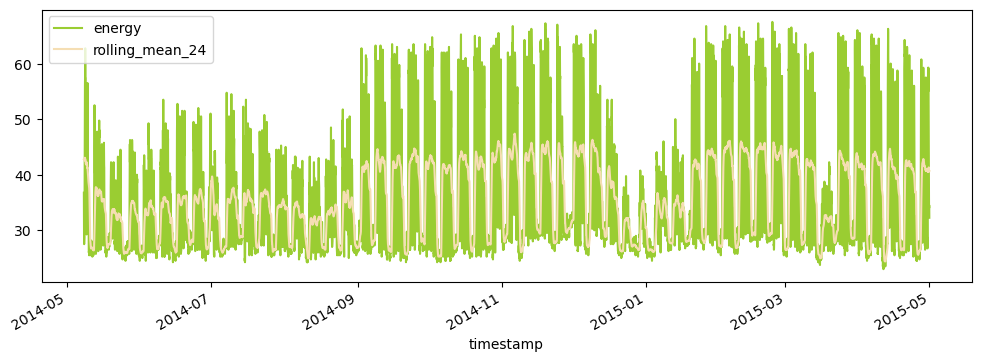

In [282]:
df[["energy","rolling_mean_24"]].plot(figsize=(12,4), color = ['yellowgreen', 'wheat'])

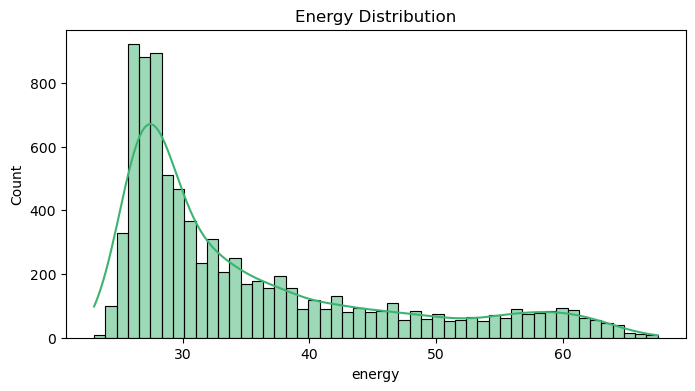

In [278]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.histplot(df["energy"], bins=50, kde=True, color = 'mediumseagreen')
plt.title("Energy Distribution")
plt.show()

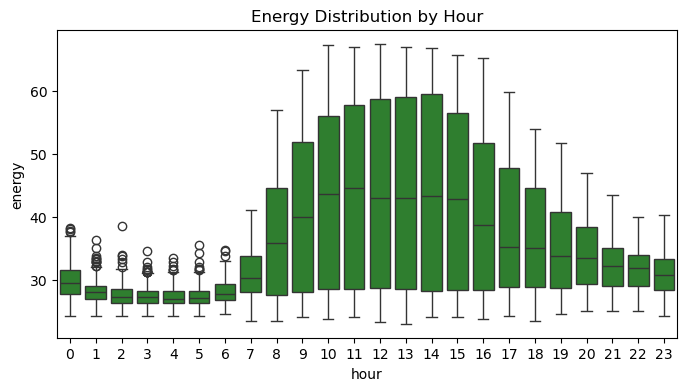

In [280]:
plt.figure(figsize=(8,4))
sns.boxplot(x="hour", y="energy", data=df, color = 'forestgreen')
plt.title("Energy Distribution by Hour")
plt.show()

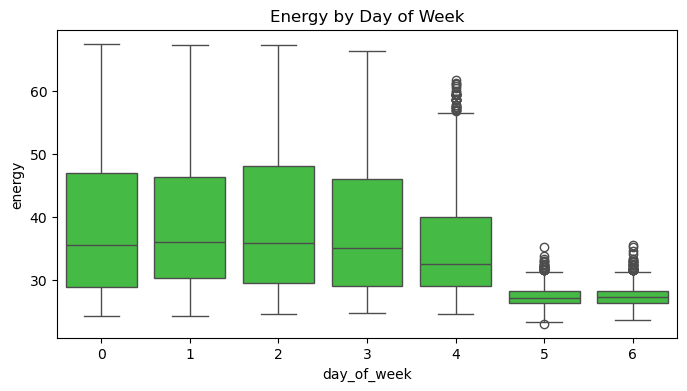

In [284]:
plt.figure(figsize=(8,4))
sns.boxplot(x="day_of_week", y="energy", data=df, color = 'limegreen')
plt.title("Energy by Day of Week")
plt.show()

Text(0.5, 1.0, 'Average Hourly Energy Profile')

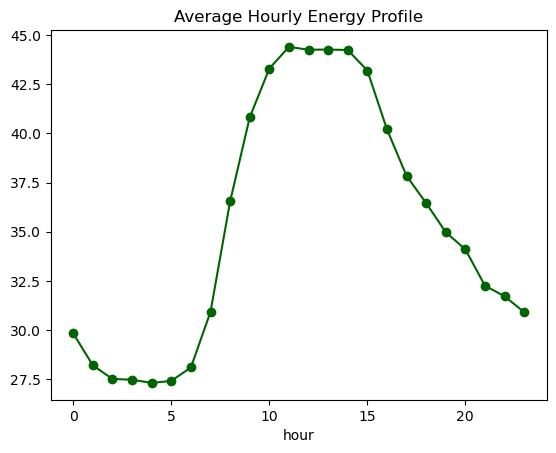

In [286]:
df.groupby("hour")["energy"].mean().plot(kind="line", marker="o", color = 'darkgreen')
plt.title("Average Hourly Energy Profile")

#### Office_Maryann

In [242]:
df = pd.read_csv(PROCESSED_PATH + "Office_Maryann_features.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.set_index("timestamp")

df.head()

,energy,hour,day_of_week,month,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend,lag_1,lag_24,lag_168,rolling_mean_24,rolling_std_24,rolling_mean_168,diff_1,pct_change
timestamp,,,,,,,,,,,,,,,,,
2014-05-08 00:00:00,13.462900,0,3,5,0.000000,1.000000,0.433884,-0.900969,0,13.065425,7.768550,9.057600,13.948045,3.647057,10.345563,0.397475,0.030422
2014-05-08 01:00:00,15.267575,1,3,5,0.258819,0.965926,0.433884,-0.900969,0,13.462900,8.924800,8.510750,14.212327,3.493817,10.385782,1.804675,0.134048
2014-05-08 02:00:00,16.935550,2,3,5,0.500000,0.866025,0.433884,-0.900969,0,15.267575,7.924800,9.554700,14.587775,3.265467,10.429716,1.667975,0.109250
2014-05-08 03:00:00,16.849625,3,3,5,0.707107,0.707107,0.433884,-0.900969,0,16.935550,7.882825,8.919925,14.961392,2.964022,10.476917,-0.085925,-0.005074
2014-05-08 04:00:00,16.721675,4,3,5,0.866025,0.500000,0.433884,-0.900969,0,16.849625,8.174800,8.366200,15.317511,2.604860,10.526652,-0.127950,-0.007594


<Axes: title={'center': 'Energy Consumption Over Time'}, xlabel='timestamp'>

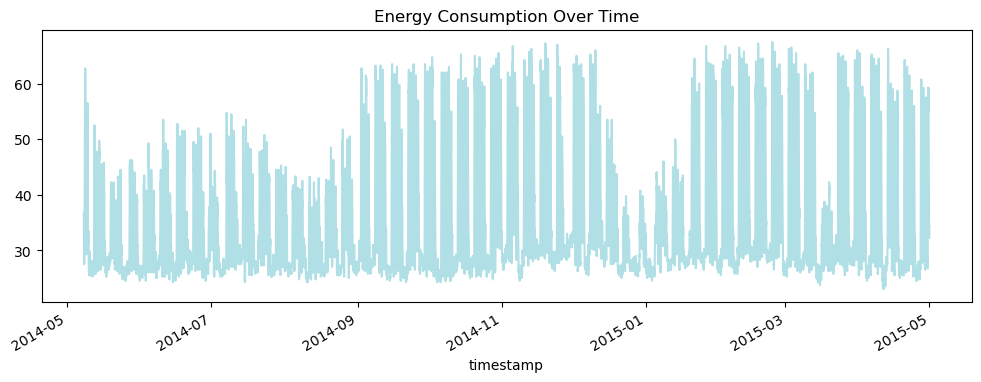

In [288]:
df["energy"].plot(figsize=(12,4), title = 'Energy Consumption Over Time', color = 'powderblue')

<Axes: xlabel='timestamp'>

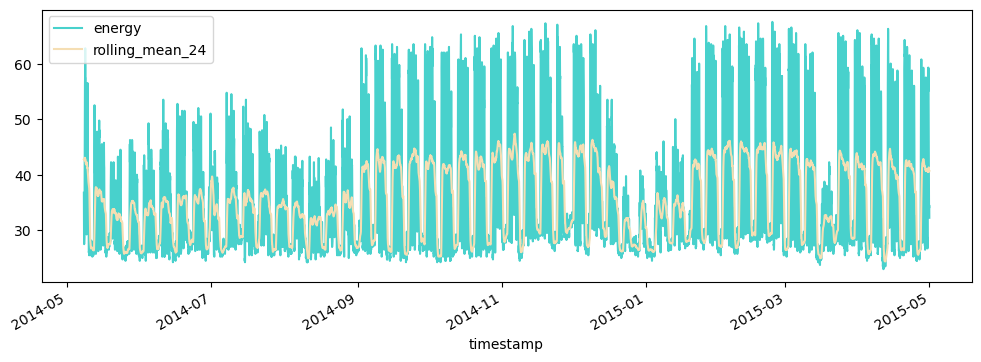

In [290]:
df[["energy","rolling_mean_24"]].plot(figsize=(12,4), color = ['mediumturquoise', 'wheat'])

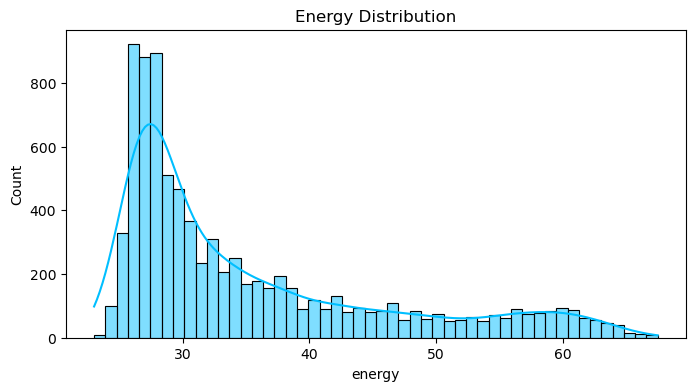

In [298]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.histplot(df["energy"], bins=50, kde=True, color = 'deepskyblue')
plt.title("Energy Distribution")
plt.show()

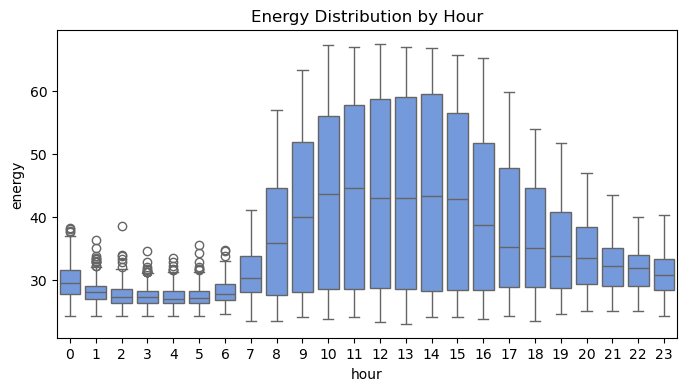

In [300]:
plt.figure(figsize=(8,4))
sns.boxplot(x="hour", y="energy", data=df, color = 'cornflowerblue')
plt.title("Energy Distribution by Hour")
plt.show()

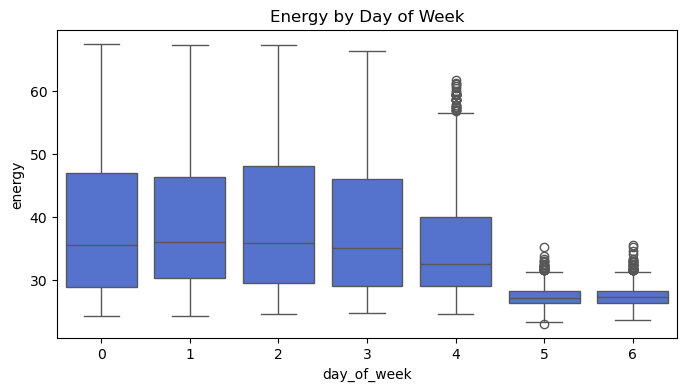

In [302]:
plt.figure(figsize=(8,4))
sns.boxplot(x="day_of_week", y="energy", data=df, color = 'royalblue')
plt.title("Energy by Day of Week")
plt.show()

Text(0.5, 1.0, 'Average Hourly Energy Profile')

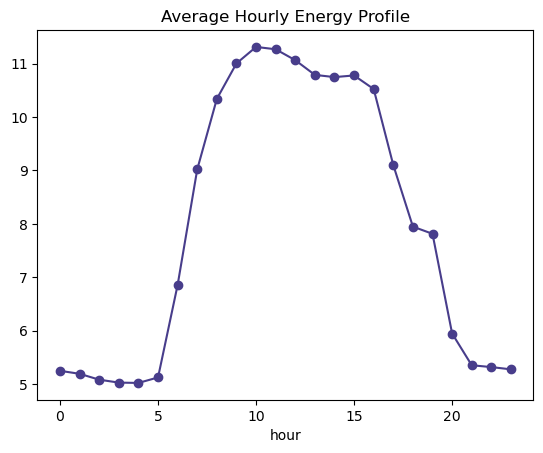

In [264]:
df.groupby("hour")["energy"].mean().plot(kind="line", marker="o", color = 'darkslateblue')
plt.title("Average Hourly Energy Profile")

#### Office_Mick

In [267]:
df = pd.read_csv(PROCESSED_PATH + "Office_Mick_features.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.set_index("timestamp")

df.head()

,energy,hour,day_of_week,month,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend,lag_1,lag_24,lag_168,rolling_mean_24,rolling_std_24,rolling_mean_168,diff_1,pct_change
timestamp,,,,,,,,,,,,,,,,,
2014-05-08 00:00:00,36.75,0,3,5,0.000000,1.000000,0.433884,-0.900969,0,35.75,35.50,29.50,42.781250,11.308979,37.961310,1.00,0.027972
2014-05-08 01:00:00,29.25,1,3,5,0.258819,0.965926,0.433884,-0.900969,0,36.75,29.50,28.00,42.770833,11.321852,37.968750,-7.50,-0.204082
2014-05-08 02:00:00,27.75,2,3,5,0.500000,0.866025,0.433884,-0.900969,0,29.25,28.75,27.25,42.729167,11.377399,37.971726,-1.50,-0.051282
2014-05-08 03:00:00,27.50,3,3,5,0.707107,0.707107,0.433884,-0.900969,0,27.75,28.75,27.25,42.677083,11.446824,37.973214,-0.25,-0.009009
2014-05-08 04:00:00,27.75,4,3,5,0.866025,0.500000,0.433884,-0.900969,0,27.50,29.25,27.00,42.614583,11.527137,37.977679,0.25,0.009091


<Axes: title={'center': 'Energy Consumption Over Time'}, xlabel='timestamp'>

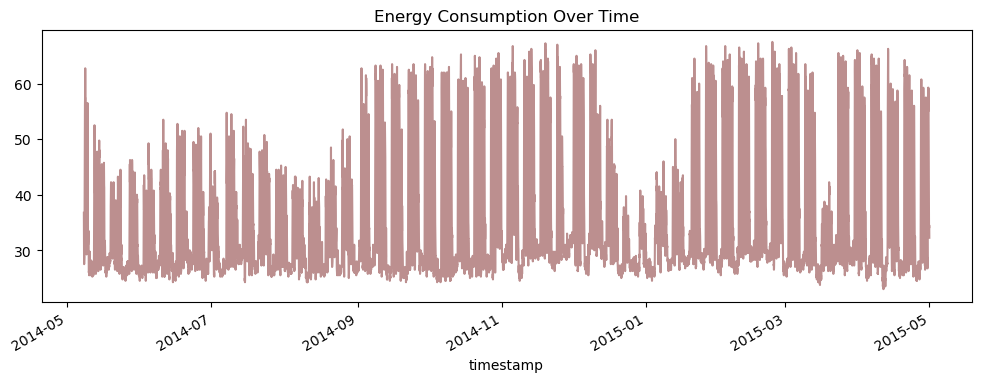

In [304]:
df["energy"].plot(figsize=(12,4), title = 'Energy Consumption Over Time', color = 'rosybrown')

<Axes: xlabel='timestamp'>

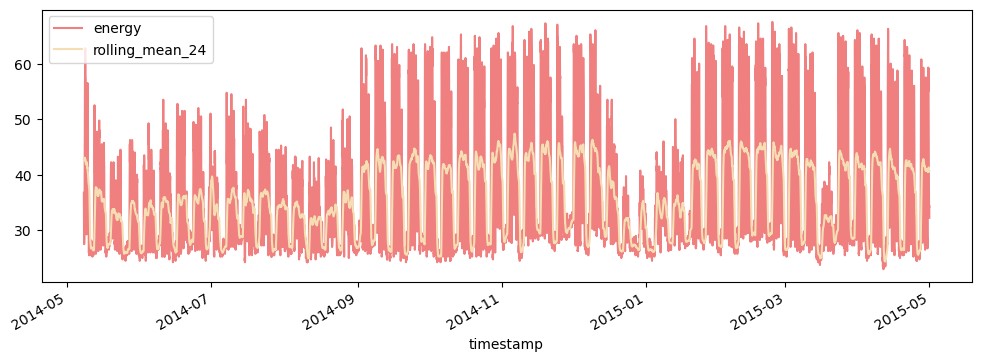

In [306]:
df[["energy","rolling_mean_24"]].plot(figsize=(12,4), color = ['lightcoral', 'wheat'])

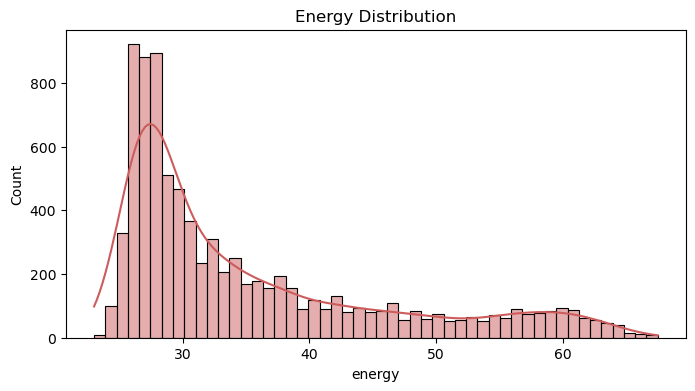

In [308]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.histplot(df["energy"], bins=50, kde=True, color = 'indianred')
plt.title("Energy Distribution")
plt.show()

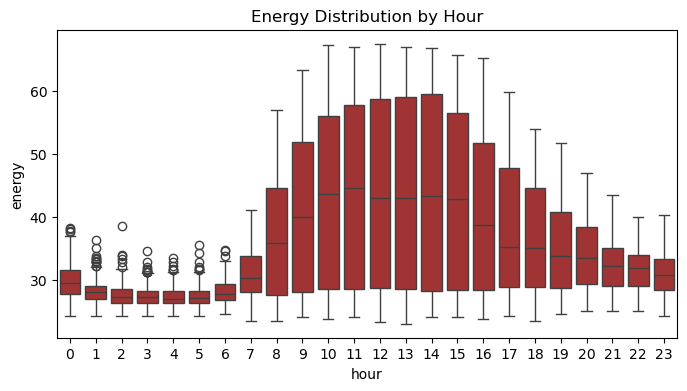

In [310]:
plt.figure(figsize=(8,4))
sns.boxplot(x="hour", y="energy", data=df, color = 'firebrick')
plt.title("Energy Distribution by Hour")
plt.show()

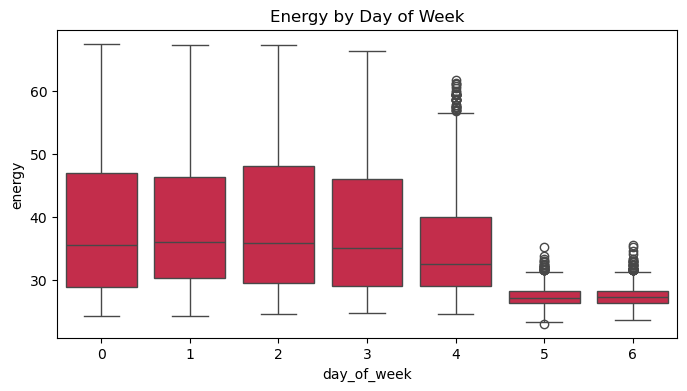

In [312]:
plt.figure(figsize=(8,4))
sns.boxplot(x="day_of_week", y="energy", data=df, color = 'crimson')
plt.title("Energy by Day of Week")
plt.show()

Text(0.5, 1.0, 'Average Hourly Energy Profile')

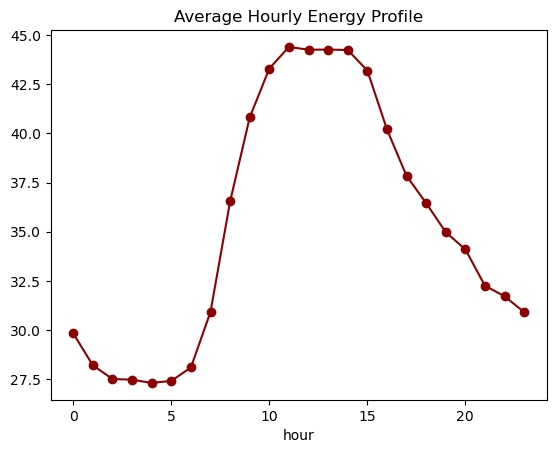

In [314]:
df.groupby("hour")["energy"].mean().plot(kind="line", marker="o", color = 'darkred')
plt.title("Average Hourly Energy Profile")